In [1]:
import xarray as xr

ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month.nc")
print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:            (year: 44, region_id: 237, number: 25)
Coordinates:
  * year               (year) int64 352B 1981 1982 1983 1984 ... 2022 2023 2024
  * region_id          (region_id) int64 2kB 0 1 2 3 4 5 ... 232 233 234 235 236
  * number             (number) int64 200B 0 1 2 3 4 5 6 ... 19 20 21 22 23 24
Data variables:
    t2m_hottest_month  (year, region_id, number) float32 1MB ...


In [2]:
# ====================================================
# GEV fit using 44 years × 25 ensemble members
# Compute 50-year return level for each region
# ====================================================

import numpy as np
import xarray as xr
from scipy.stats import genextreme as gev
from tqdm import tqdm

# ====================================================
# 0. User settings
# ====================================================
INPUT_FILE  = "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/Bias_correction_ibicus/IFS_hottest_month_bias_corrected_ibicus_CDFt_trend_restored.nc"
#INPUT_FILE  = "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month.nc"          # <-- 改成你的 nc 文件名
OUTPUT_FILE = "GEV_RL50_by_region.nc"
RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 50   # 防止极端小样本

np.random.seed(42)

# ====================================================
# 1. Load dataset
# ====================================================
ds = xr.open_dataset(INPUT_FILE)
da = ds["t2m_hottest_month_bc"]

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded dataset with {n_region} regions")

# ====================================================
# 2. Allocate output arrays
# ====================================================
rl50  = np.full(n_region, np.nan, dtype=np.float32)
shape = np.full(n_region, np.nan, dtype=np.float32)
loc   = np.full(n_region, np.nan, dtype=np.float32)
scale = np.full(n_region, np.nan, dtype=np.float32)
nsamp = np.zeros(n_region, dtype=np.int32)

# ====================================================
# 3. Loop over regions
# ====================================================
for i, rid in enumerate(tqdm(regions, desc="Fitting GEV by region")):

    # Extract samples: (year, number) → 1D
    samples = da.sel(region_id=rid).values.reshape(-1)

    # Remove NaNs
    samples = samples[np.isfinite(samples)]
    nsamp[i] = len(samples)

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        # -----------------------------
        # Fit stationary GEV
        # -----------------------------
        c, loc_i, scale_i = gev.fit(samples)

        # -----------------------------
        # 50-year return level
        # -----------------------------
        p = 1 - 1 / RETURN_PERIOD
        rl50[i] = gev.ppf(p, c, loc=loc_i, scale=scale_i)

        # Save parameters
        shape[i] = c
        loc[i]   = loc_i
        scale[i] = scale_i

    except Exception:
        # Fit failed → keep NaN
        continue

# ====================================================
# 4. Create output Dataset
# ====================================================
out_ds = xr.Dataset(
    data_vars=dict(
        rl50 = (["region_id"], rl50),
        gev_shape = (["region_id"], shape),
        gev_loc   = (["region_id"], loc),
        gev_scale = (["region_id"], scale),
        sample_size = (["region_id"], nsamp),
    ),
    coords=dict(
        region_id = regions
    ),
    attrs=dict(
        description = "GEV fitted using 44 years × 25 ensemble members",
        return_period = f"{RETURN_PERIOD}-year",
        variable = "t2m_hottest_month",
        distribution = "GEV (scipy.stats.genextreme)",
        note = "SciPy shape parameter c = -xi"
    )
)

# ====================================================
# 5. Save to NetCDF
# ====================================================
out_ds.to_netcdf(OUTPUT_FILE)

print(f"Saved return levels to: {OUTPUT_FILE}")


Loaded dataset with 237 regions


Fitting GEV by region: 100%|██████████| 237/237 [00:09<00:00, 24.51it/s]


Saved return levels to: GEV_RL50_by_region.nc


Loaded 237 regions


ENSO probabilities: 100%|██████████| 237/237 [00:00<00:00, 709.10it/s]


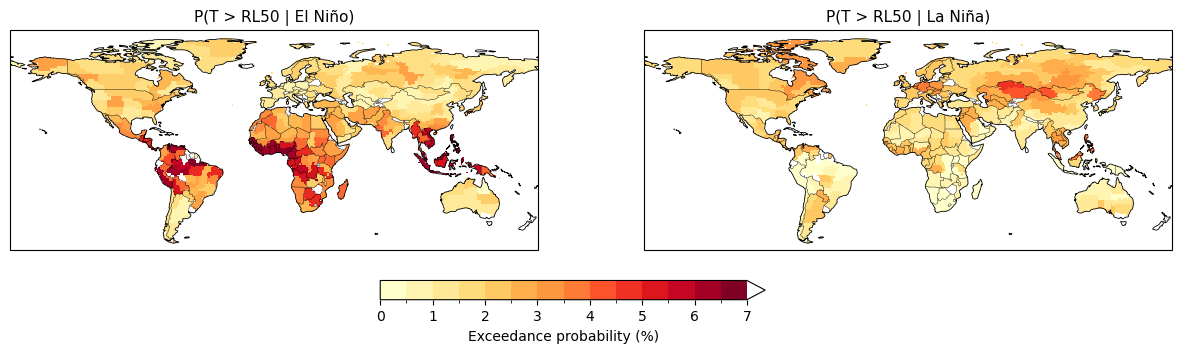

In [13]:
# ====================================================
# ENSO conditional exceedance probability of RL50
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter

# ====================================================
# 0. User settings
# ====================================================
DATA_FILE = "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month.nc"

REGION_MASK_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 100

# ---- ENSO years ----
EL_NINO_YEARS = [
    1982, 1983,
    1986, 1987, 1988,
    1991, 1992,
    1997, 1998,
    2002, 2003,
    2009, 2010,
    2015, 2016,
    2023, 2024
]

LA_NINA_YEARS = [
    1984, 1985,
    1988, 1989,
    1998, 1999, 2000,
    2007, 2008,
    2010, 2011, 2012,
    2020, 2021, 2022
]

# ====================================================
# 1. Load data
# ====================================================
ds = xr.open_dataset(DATA_FILE)
da = ds["t2m_hottest_month"]

region_mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = region_mask_ds["region_id"]

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded {n_region} regions")

# ====================================================
# 2. Split ENSO years
# ====================================================
da_el = da.sel(year=da.year.isin(EL_NINO_YEARS))
da_la = da.sel(year=da.year.isin(LA_NINA_YEARS))

# ====================================================
# 3. Fit GEV using all years → RL50
# ====================================================
rl50 = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="GEV fit (1981–2024)")):
    samples = da.sel(region_id=rid).values.reshape(-1)
    samples = samples[np.isfinite(samples)]

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        c, loc, scale = gev.fit(samples)
        rl50[i] = gev.ppf(
            1 - 1 / RETURN_PERIOD,
            c,
            loc=loc,
            scale=scale
        )
    except Exception:
        continue

# ====================================================
# 4. ENSO conditional exceedance probabilities
# ====================================================
p_el = np.full(n_region, np.nan)
p_la = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="ENSO probabilities")):

    threshold = rl50[i]
    if not np.isfinite(threshold):
        continue

    # ---- El Niño ----
    el_samples = da_el.sel(region_id=rid).values.reshape(-1)
    el_samples = el_samples[np.isfinite(el_samples)]

    if len(el_samples) > 0:
        p_el[i] = np.mean(el_samples > threshold)

    # ---- La Niña ----
    la_samples = da_la.sel(region_id=rid).values.reshape(-1)
    la_samples = la_samples[np.isfinite(la_samples)]

    if len(la_samples) > 0:
        p_la[i] = np.mean(la_samples > threshold)

# ====================================================
# 5. Map region values back to 1° grid
# ====================================================
p_el_map = xr.full_like(region_mask, np.nan, dtype=float)
p_la_map = xr.full_like(region_mask, np.nan, dtype=float)

for i, rid in enumerate(regions):
    p_el_map = xr.where(region_mask == rid, p_el[i], p_el_map)
    p_la_map = xr.where(region_mask == rid, p_la[i], p_la_map)

# ====================================================
# 6. Plot maps (colorbar in %)
# ====================================================
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    subplot_kw=dict(projection=proj)
)

levels = np.linspace(0, 0.07, 15)

for ax, data, title in zip(
    axes,
    [p_el_map, p_la_map],
    ["El Niño", "La Niña"]
):
    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        levels=levels,
        add_colorbar=False
    )

    ax.set_title(
        f"P(T > RL50 | {title})",
        fontsize=11
    )

# ---- Colorbar with percentage formatter ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    extend="max"
)

cbar.set_label("Exceedance probability (%)")

cbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x * 100:.0f}")
)
plt.savefig("role_of_ENSO.png", dpi=300, bbox_inches='tight')
plt.show()


Loaded 237 regions


ENSO probabilities: 100%|██████████| 237/237 [00:00<00:00, 465.93it/s]


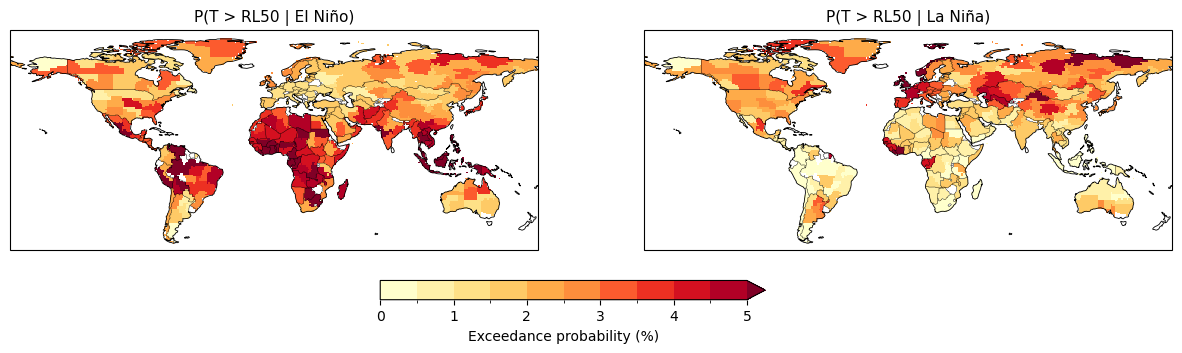

In [4]:
# ====================================================
# ENSO conditional exceedance probability of RL50
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter

# ====================================================
# 0. User settings
# ====================================================
DATA_FILE = "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/Bias_correction_ibicus/IFS_hottest_month_bias_corrected_ibicus_CDFt_trend_restored.nc"

REGION_MASK_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 100

# ---- ENSO years ----
EL_NINO_YEARS = [
    1982, 1983,
    1986, 1987, 1988,
    1991, 1992,
    1997, 1998,
    2002, 2003,
    2009, 2010,
    2015, 2016,
    2023, 2024
]

LA_NINA_YEARS = [
    1984, 1985,
    1988, 1989,
    1998, 1999, 2000,
    2007, 2008,
    2010, 2011, 2012,
    2020, 2021, 2022
]

# ====================================================
# 1. Load data
# ====================================================
ds = xr.open_dataset(DATA_FILE)
da = ds["t2m_hottest_month_bc"]

region_mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = region_mask_ds["region_id"]

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded {n_region} regions")

# ====================================================
# 2. Split ENSO years
# ====================================================
da_el = da.sel(year=da.year.isin(EL_NINO_YEARS))
da_la = da.sel(year=da.year.isin(LA_NINA_YEARS))

# ====================================================
# 3. Fit GEV using all years → RL50
# ====================================================
rl50 = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="GEV fit (1981–2024)")):
    samples = da.sel(region_id=rid).values.reshape(-1)
    samples = samples[np.isfinite(samples)]

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        c, loc, scale = gev.fit(samples)
        rl50[i] = gev.ppf(
            1 - 1 / RETURN_PERIOD,
            c,
            loc=loc,
            scale=scale
        )
    except Exception:
        continue

# ====================================================
# 4. ENSO conditional exceedance probabilities
# ====================================================
p_el = np.full(n_region, np.nan)
p_la = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="ENSO probabilities")):

    threshold = rl50[i]
    if not np.isfinite(threshold):
        continue

    # ---- El Niño ----
    el_samples = da_el.sel(region_id=rid).values.reshape(-1)
    el_samples = el_samples[np.isfinite(el_samples)]

    if len(el_samples) > 0:
        p_el[i] = np.mean(el_samples > threshold)

    # ---- La Niña ----
    la_samples = da_la.sel(region_id=rid).values.reshape(-1)
    la_samples = la_samples[np.isfinite(la_samples)]

    if len(la_samples) > 0:
        p_la[i] = np.mean(la_samples > threshold)

# ====================================================
# 5. Map region values back to 1° grid
# ====================================================
p_el_map = xr.full_like(region_mask, np.nan, dtype=float)
p_la_map = xr.full_like(region_mask, np.nan, dtype=float)

for i, rid in enumerate(regions):
    p_el_map = xr.where(region_mask == rid, p_el[i], p_el_map)
    p_la_map = xr.where(region_mask == rid, p_la[i], p_la_map)

# ====================================================
# 6. Plot maps (BoundaryNorm + colored extend)
# ====================================================
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    subplot_kw=dict(projection=proj)
)

# ---- color settings ----
levels = np.linspace(0, 0.05, 11)
cmap = plt.get_cmap("YlOrRd")
norm = BoundaryNorm(levels, cmap.N, extend="max")

for ax, data, title in zip(
    axes,
    [p_el_map, p_la_map],
    ["El Niño", "La Niña"]
):
    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.set_title(
        f"P(T > RL50 | {title})",
        fontsize=11
    )

# ---- colorbar ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    extend="max"
)

cbar.set_label("Exceedance probability (%)")
cbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x * 100:.0f}")
)
plt.savefig("role_of_ENSO.png", dpi=300, bbox_inches='tight')
plt.show()


Loaded 237 regions


ENSO probabilities: 100%|██████████| 237/237 [00:00<00:00, 317.17it/s]


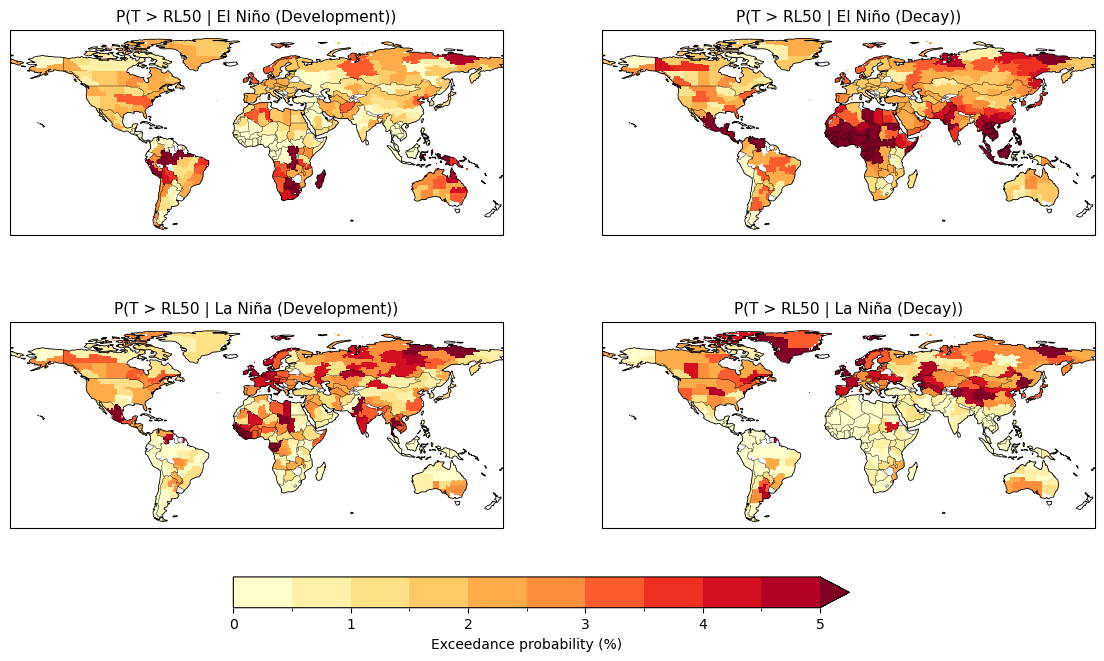

In [5]:
# ====================================================
# ENSO conditional exceedance probability of RL50
# Development vs Decay years
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter

# ====================================================
# 0. User settings
# ====================================================
DATA_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/hottestmonth/Bias_correction_ibicus/"
    "IFS_hottest_month_bias_corrected_ibicus_CDFt_trend_restored.nc"
)

REGION_MASK_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 100

# ====================================================
# ENSO development / decay years
# ====================================================

EL_NINO_DEV = [
    1982, 1986, 1991, 1993, 1994,
    1997, 2002, 2004, 2006,
    2009, 2014, 2018, 2023
]

EL_NINO_DEC = [
    1983, 1988, 1992, 1994, 1995,
    1998, 2003, 2005, 2007,
    2010, 2016, 2019, 2024
]

LA_NINA_DEV = [
    1984, 1988, 1998, 2007,
    2010, 2020
]

LA_NINA_DEC = [
    1985, 1989, 2000, 2008,
    2012, 2022
]

# ====================================================
# 1. Load data
# ====================================================
ds = xr.open_dataset(DATA_FILE)
da = ds["t2m_hottest_month_bc"]

region_mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = region_mask_ds["region_id"]

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded {n_region} regions")

# ====================================================
# 2. Subset ENSO samples
# ====================================================
da_en_dev = da.sel(year=da.year.isin(EL_NINO_DEV))
da_en_dec = da.sel(year=da.year.isin(EL_NINO_DEC))
da_ln_dev = da.sel(year=da.year.isin(LA_NINA_DEV))
da_ln_dec = da.sel(year=da.year.isin(LA_NINA_DEC))

# ====================================================
# 3. Fit GEV using ALL years → RL50
# ====================================================
rl50 = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="GEV fit (1981–2024)")):
    samples = da.sel(region_id=rid).values.reshape(-1)
    samples = samples[np.isfinite(samples)]

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        c, loc, scale = gev.fit(samples)
        rl50[i] = gev.ppf(
            1 - 1 / RETURN_PERIOD,
            c,
            loc=loc,
            scale=scale
        )
    except Exception:
        continue

# ====================================================
# 4. ENSO conditional exceedance probabilities
# ====================================================
p_en_dev = np.full(n_region, np.nan)
p_en_dec = np.full(n_region, np.nan)
p_ln_dev = np.full(n_region, np.nan)
p_ln_dec = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="ENSO probabilities")):

    threshold = rl50[i]
    if not np.isfinite(threshold):
        continue

    def exceed_prob(da_sub):
        samples = da_sub.sel(region_id=rid).values.reshape(-1)
        samples = samples[np.isfinite(samples)]
        if len(samples) == 0:
            return np.nan
        return np.mean(samples > threshold)

    p_en_dev[i] = exceed_prob(da_en_dev)
    p_en_dec[i] = exceed_prob(da_en_dec)
    p_ln_dev[i] = exceed_prob(da_ln_dev)
    p_ln_dec[i] = exceed_prob(da_ln_dec)

# ====================================================
# 5. Map region values back to 1° grid
# ====================================================
def map_to_grid(values):
    out = xr.full_like(region_mask, np.nan, dtype=float)
    for i, rid in enumerate(regions):
        out = xr.where(region_mask == rid, values[i], out)
    return out

maps = [
    map_to_grid(p_en_dev),
    map_to_grid(p_en_dec),
    map_to_grid(p_ln_dev),
    map_to_grid(p_ln_dec)
]

titles = [
    "El Niño (Development)",
    "El Niño (Decay)",
    "La Niña (Development)",
    "La Niña (Decay)"
]

# ====================================================
# 6. Plot 2×2 maps
# ====================================================
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    subplot_kw=dict(projection=proj)
)

levels = np.linspace(0, 0.05, 11)
cmap = plt.get_cmap("YlOrRd")
norm = BoundaryNorm(levels, cmap.N, extend="max")

for ax, data, title in zip(axes.flat, maps, titles):
    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.set_title(f"P(T > RL50 | {title})", fontsize=11)

# ---- shared colorbar ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    extend="max"
)

cbar.set_label("Exceedance probability (%)")
cbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x * 100:.0f}")
)

plt.savefig("ENSO_dev_decay_RL50_exceedance.png", dpi=300, bbox_inches="tight")
plt.show()


Loaded 237 regions


ENSO probabilities: 100%|██████████| 237/237 [00:00<00:00, 453.92it/s]


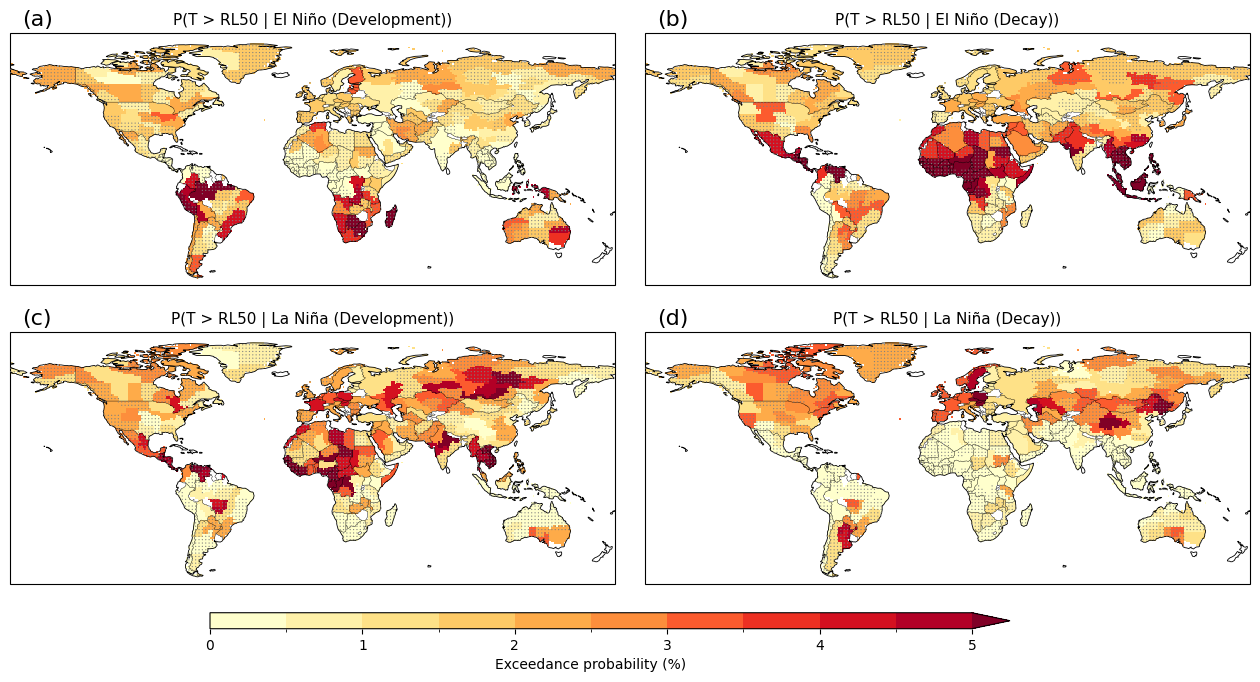

In [3]:
# ====================================================
# ENSO conditional exceedance probability of RL50
# Development vs Decay years
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter

# ====================================================
# 0. User settings
# ====================================================
DATA_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month_bias_corrected.nc"
)

REGION_MASK_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

# fidelity 数据
FIDELITY_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)
RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 100

# scatter 稀疏间隔（每隔几个格点打一个点）
SCATTER_STEP = 2

# ====================================================
# ENSO development / decay years
# ====================================================
EL_NINO_DEV = [
    1982, 1986, 1991, 1993, 1994,
    1997, 2002, 2004, 2006,
    2009, 2014, 2018, 2023
]

EL_NINO_DEC = [
    1983, 1988, 1992, 1994, 1995,
    1998, 2003, 2005, 2007,
    2010, 2016, 2019, 2024
]

LA_NINA_DEV = [
    1984, 1988, 1998, 2007,
    2010, 2020
]

LA_NINA_DEC = [
    1985, 1989, 2000, 2008,
    2012, 2022
]

# ====================================================
# 1. Load data
# ====================================================
ds = xr.open_dataset(DATA_FILE)
da = ds["t2m_hottest_month"]

region_mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = region_mask_ds["region_id"]

# 经纬度
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

# fidelity mask
fidelity_ds = xr.open_dataset(FIDELITY_FILE)
fidelity = fidelity_ds["fidelity_score"]

# fidelity = 3 为高保真；非3且非NaN为低保真
low_fidelity_mask = (fidelity != 3) & np.isfinite(fidelity)

# 构造稀疏scatter mask
mask_sparse = low_fidelity_mask.values.copy()
mask_sparse[::SCATTER_STEP, ::SCATTER_STEP] = \
    low_fidelity_mask.values[::SCATTER_STEP, ::SCATTER_STEP]

# 仅保留稀疏点
sparse_mask = np.zeros_like(mask_sparse, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask.values & sparse_mask

# meshgrid 用于 scatter
lon2d, lat2d = np.meshgrid(lon, lat)

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded {n_region} regions")

# ====================================================
# 2. Subset ENSO samples
# ====================================================
da_en_dev = da.sel(year=da.year.isin(EL_NINO_DEV))
da_en_dec = da.sel(year=da.year.isin(EL_NINO_DEC))
da_ln_dev = da.sel(year=da.year.isin(LA_NINA_DEV))
da_ln_dec = da.sel(year=da.year.isin(LA_NINA_DEC))

# ====================================================
# 3. Fit GEV using ALL years → RL50
# ====================================================
rl50 = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="GEV fit (1981–2024)")):
    samples = da.sel(region_id=rid).values.reshape(-1)
    samples = samples[np.isfinite(samples)]

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        c, loc, scale = gev.fit(samples)
        rl50[i] = gev.ppf(
            1 - 1 / RETURN_PERIOD,
            c,
            loc=loc,
            scale=scale
        )
    except Exception:
        continue

# ====================================================
# 4. ENSO conditional exceedance probabilities
# ====================================================
p_en_dev = np.full(n_region, np.nan)
p_en_dec = np.full(n_region, np.nan)
p_ln_dev = np.full(n_region, np.nan)
p_ln_dec = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="ENSO probabilities")):

    threshold = rl50[i]
    if not np.isfinite(threshold):
        continue

    def exceed_prob(da_sub):
        samples = da_sub.sel(region_id=rid).values.reshape(-1)
        samples = samples[np.isfinite(samples)]
        if len(samples) == 0:
            return np.nan
        return np.mean(samples > threshold)

    p_en_dev[i] = exceed_prob(da_en_dev)
    p_en_dec[i] = exceed_prob(da_en_dec)
    p_ln_dev[i] = exceed_prob(da_ln_dev)
    p_ln_dec[i] = exceed_prob(da_ln_dec)

# ====================================================
# 5. Map region values back to 1° grid
# ====================================================
def map_to_grid(values):
    out = xr.full_like(region_mask, np.nan, dtype=float)
    for i, rid in enumerate(regions):
        out = xr.where(region_mask == rid, values[i], out)
    return out

maps = [
    map_to_grid(p_en_dev),
    map_to_grid(p_en_dec),
    map_to_grid(p_ln_dev),
    map_to_grid(p_ln_dec)
]

titles = [
    "El Niño (Development)",
    "El Niño (Decay)",
    "La Niña (Development)",
    "La Niña (Decay)"
]

# ====================================================
# 6. Plot 2×2 maps
# ====================================================
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    subplot_kw=dict(projection=proj)
)

levels = np.linspace(0, 0.05, 11)
cmap = plt.get_cmap("YlOrRd")
norm = BoundaryNorm(levels, cmap.N, extend="max")

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, data, title, label in zip(
        axes.flat, maps, titles, panel_labels):

    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent([-180, 180, -60, 90],
                  crs=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    # ---- 低保真区域 scatter ----
    ax.scatter(
        lon2d[low_fidelity_sparse],
        lat2d[low_fidelity_sparse],
        s=0.8,
        color="grey",
        marker="o",
        alpha=1,
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    # 标题加序号

    ax.text(0.02, 1.03, label, transform=ax.transAxes,fontsize=16)

    ax.set_title(
        f"P(T > RL50 | {title})",
        fontsize=11
    )

# 子图间距
fig.subplots_adjust(
    wspace=0.05,
    hspace=0.02,
    top=0.92,
    bottom=0.18
)

# ---- 使用 add_axes 控制 colorbar ----
cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.02])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
    extend="max"
)

cbar.set_label("Exceedance probability (%)")
cbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x * 100:.0f}")
)

plt.savefig(
    "ENSO_dev_decay_RL50_exceedance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Loaded 237 regions


ENSO probabilities: 100%|██████████| 237/237 [00:00<00:00, 457.52it/s]


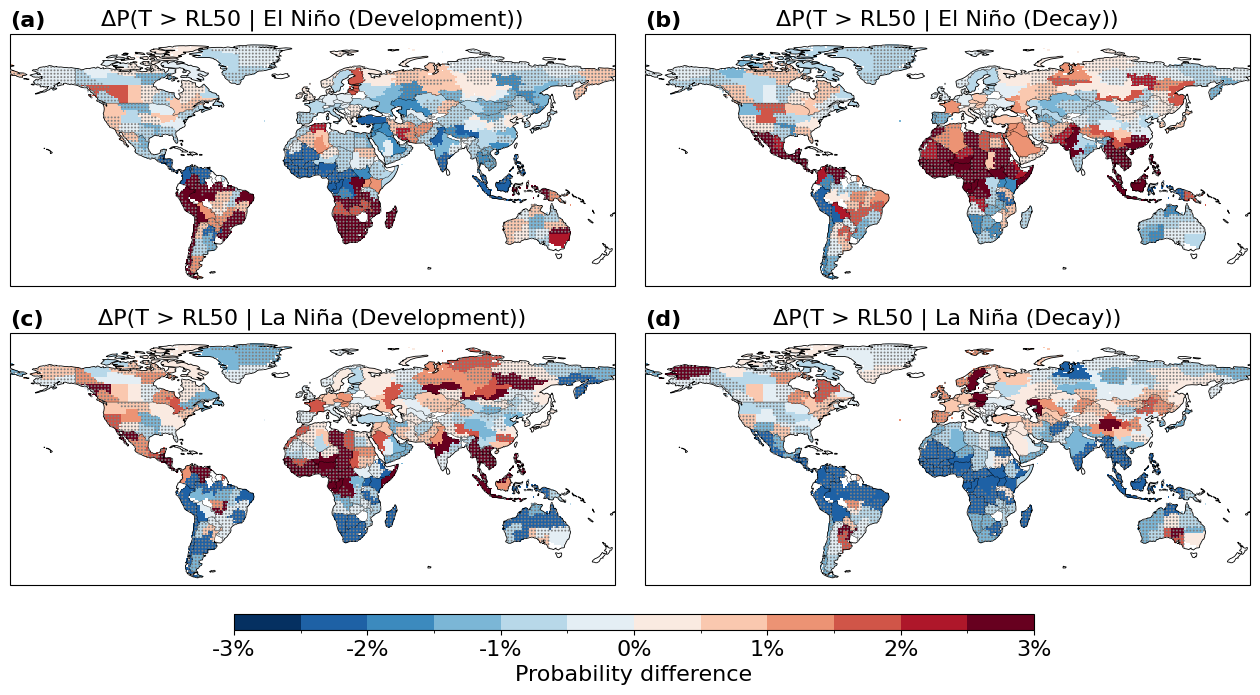

In [1]:
# ====================================================
# ENSO conditional exceedance probability of RL50
# Development vs Decay years
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter

# ====================================================
# 0. User settings
# ====================================================
DATA_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month_bias_corrected.nc"
)

REGION_MASK_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

FIDELITY_FILE = (
    "/home/users/kastanie/Global_regional_analysis/"
    "atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)

RETURN_PERIOD = 50
MIN_SAMPLE_SIZE = 100

# baseline probability
BASELINE = 0.02

SCATTER_STEP = 2

# ====================================================
# ENSO development / decay years
# ====================================================
EL_NINO_DEV = [
    1982, 1986, 1991, 1997,
    2002, 2004, 2006,
    2009, 2015, 2018, 2023
]

EL_NINO_DEC = [
    1983, 1987, 1992, 1998,
    2003, 2005, 2007,
    2010, 2016, 2019, 2024
]

LA_NINA_DEV = [
    1984, 1988, 1998, 2007,
    2010, 2016, 2020
]

LA_NINA_DEC = [
    1985, 1989, 2001, 2008,
    2012, 2017, 2022
]

# ====================================================
# 1. Load data
# ====================================================
ds = xr.open_dataset(DATA_FILE)
da = ds["t2m_hottest_month"]

region_mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = region_mask_ds["region_id"]

lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

fidelity_ds = xr.open_dataset(FIDELITY_FILE)
fidelity = fidelity_ds["fidelity_score"]

low_fidelity_mask = (fidelity != 3) & np.isfinite(fidelity)

mask_sparse = low_fidelity_mask.values.copy()
mask_sparse[::SCATTER_STEP, ::SCATTER_STEP] = \
    low_fidelity_mask.values[::SCATTER_STEP, ::SCATTER_STEP]

sparse_mask = np.zeros_like(mask_sparse, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask.values & sparse_mask

lon2d, lat2d = np.meshgrid(lon, lat)

regions = ds.region_id.values
n_region = len(regions)

print(f"Loaded {n_region} regions")

# ====================================================
# 2. Subset ENSO samples
# ====================================================
da_en_dev = da.sel(year=da.year.isin(EL_NINO_DEV))
da_en_dec = da.sel(year=da.year.isin(EL_NINO_DEC))
da_ln_dev = da.sel(year=da.year.isin(LA_NINA_DEV))
da_ln_dec = da.sel(year=da.year.isin(LA_NINA_DEC))

# ====================================================
# 3. Fit GEV using ALL years → RL50
# ====================================================
rl50 = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="GEV fit (1981–2024)")):

    samples = da.sel(region_id=rid).values.reshape(-1)
    samples = samples[np.isfinite(samples)]

    if len(samples) < MIN_SAMPLE_SIZE:
        continue

    try:
        c, loc, scale = gev.fit(samples)
        rl50[i] = gev.ppf(
            1 - 1 / RETURN_PERIOD,
            c,
            loc=loc,
            scale=scale
        )
    except Exception:
        continue

# ====================================================
# 4. ENSO conditional exceedance probabilities
# ====================================================
p_en_dev = np.full(n_region, np.nan)
p_en_dec = np.full(n_region, np.nan)
p_ln_dev = np.full(n_region, np.nan)
p_ln_dec = np.full(n_region, np.nan)

for i, rid in enumerate(tqdm(regions, desc="ENSO probabilities")):

    threshold = rl50[i]
    if not np.isfinite(threshold):
        continue

    def exceed_prob(da_sub):
        samples = da_sub.sel(region_id=rid).values.reshape(-1)
        samples = samples[np.isfinite(samples)]
        if len(samples) == 0:
            return np.nan
        return np.mean(samples > threshold)

    p_en_dev[i] = exceed_prob(da_en_dev)
    p_en_dec[i] = exceed_prob(da_en_dec)
    p_ln_dev[i] = exceed_prob(da_ln_dev)
    p_ln_dec[i] = exceed_prob(da_ln_dec)

# ====================================================
# 5. subtract baseline (2%)
# ====================================================
p_en_dev = p_en_dev - BASELINE
p_en_dec = p_en_dec - BASELINE
p_ln_dev = p_ln_dev - BASELINE
p_ln_dec = p_ln_dec - BASELINE

# ====================================================
# 6. Map region values back to grid
# ====================================================
def map_to_grid(values):
    out = xr.full_like(region_mask, np.nan, dtype=float)
    for i, rid in enumerate(regions):
        out = xr.where(region_mask == rid, values[i], out)
    return out

maps = [
    map_to_grid(p_en_dev),
    map_to_grid(p_en_dec),
    map_to_grid(p_ln_dev),
    map_to_grid(p_ln_dec)
]

titles = [
    "El Niño (Development)",
    "El Niño (Decay)",
    "La Niña (Development)",
    "La Niña (Decay)"
]

# ====================================================
# 7. Plot maps
# ====================================================
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    subplot_kw=dict(projection=proj)
)

# diverging levels
levels = np.linspace(-0.03, 0.03, 13)

cmap = plt.get_cmap("RdBu_r")
norm = BoundaryNorm(levels, cmap.N)

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, data, title, label in zip(
        axes.flat, maps, titles, panel_labels):

    ax.set_global()
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_extent([-180, 180, -60, 90],
                  crs=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.scatter(
        lon2d[low_fidelity_sparse],
        lat2d[low_fidelity_sparse],
        s=2,
        color="grey",
        marker="o",
        alpha=1,
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(0.0, 1.03, label,
            transform=ax.transAxes,
            fontsize=16, fontweight='bold')

    ax.set_title(
        f"ΔP(T > RL50 | {title})",
        fontsize=16
    )

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.02,
    top=0.92,
    bottom=0.18
)

# ====================================================
# colorbar
# ====================================================
cbar_ax = fig.add_axes([0.265, 0.15, 0.5, 0.02])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("Probability difference", fontsize = 16)

cbar.ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x * 100:.0f}%")
)
cbar.ax.tick_params(labelsize=16)
plt.savefig(
    "FigS5_ENSO_dev_decay_RL50_probability_difference.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()